# MSME Shop-Location Opportunity Analysis & Predictive Model

This notebook is a full, standalone, run-anywhere version of the analysis:

1. Load & merge the 3 sector datasets (Trade / Manufacturing / Services)
2. Exploratory data analysis (competition landscape, sector mix, state comparisons)
3. Feature engineering (competition, fragmentation, formalization, location quotient)
4. Explainable composite **Opportunity Score**
5. Unsupervised **segmentation** (KMeans) into opportunity tiers
6. Supervised **predictive classifier** (RandomForest) that can score *any* new district
7. Rankings, visualizations, and a reusable `predict_new_district()` function

**Input:** 3 CSVs with columns `state_name, state_id, district_name, lg_dt_code, medium, micro, small, total`
(one row per district). If your column names differ, rename them to match before running.

**Note on scope:** this model scores *market structure / competition*, not revenue or footfall.
There's no population, income, or rent data here — treat outputs as a shortlisting tool.


## 0. Setup

In [1]:
# If running in a fresh environment, uncomment:
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import joblib

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)


## 1. Load data

Point these at your three sector CSVs. In the original project:
- `MAIN_DATASET1.csv` -> **Trade**
- `MAIN_DATASET2.csv` -> **Manufacturing**
- `MAIN_DATASET3.csv` -> **Services**

(This mapping was inferred from national sector totals — adjust the labels below if you know
the true sector for each file in your own data.)


In [2]:
TRADE_CSV = "MAIN_DATASET1.csv"
MANUFACTURING_CSV = "MAIN_DATASET2.csv"
SERVICES_CSV = "MAIN_DATASET3.csv"

SECTORS = ["Trade", "Manufacturing", "Services"]

d1 = pd.read_csv(TRADE_CSV); d1["sector"] = "Trade"
d2 = pd.read_csv(MANUFACTURING_CSV); d2["sector"] = "Manufacturing"
d3 = pd.read_csv(SERVICES_CSV); d3["sector"] = "Services"

df = pd.concat([d1, d2, d3], ignore_index=True)
df["district_name"] = df["district_name"].str.strip().str.upper()
df["state_name"] = df["state_name"].str.strip().str.upper()

print(df.shape)
df.head()


(2364, 9)


,state_name,state_id,district_name,lg_dt_code,medium,micro,small,total,sector
0,ANDHRA PRADESH,28,SRIKAKULAM,519,17,64721,409,65147,Trade
1,ANDHRA PRADESH,28,TIRUPATI,752,18,80656,242,80916,Trade
2,ANDHRA PRADESH,28,VISAKHAPATNAM,520,154,125312,1849,127315,Trade
3,ANDHRA PRADESH,28,VIZIANAGARAM,521,19,57939,364,58322,Trade
4,ANDHRA PRADESH,28,Y.S.R,504,28,108155,734,108917,Trade


## 2. Exploratory Data Analysis

In [3]:
print("States/UTs covered:", df['state_name'].nunique())
print("Districts covered:", df['district_name'].nunique())
print()
print("National totals by sector:")
print(df.groupby("sector")["total"].sum().sort_values(ascending=False))


States/UTs covered: 36
Districts covered: 783

National totals by sector:
sector
Trade            47155579
Services         35346268
Manufacturing    11855931
Name: total, dtype: int64


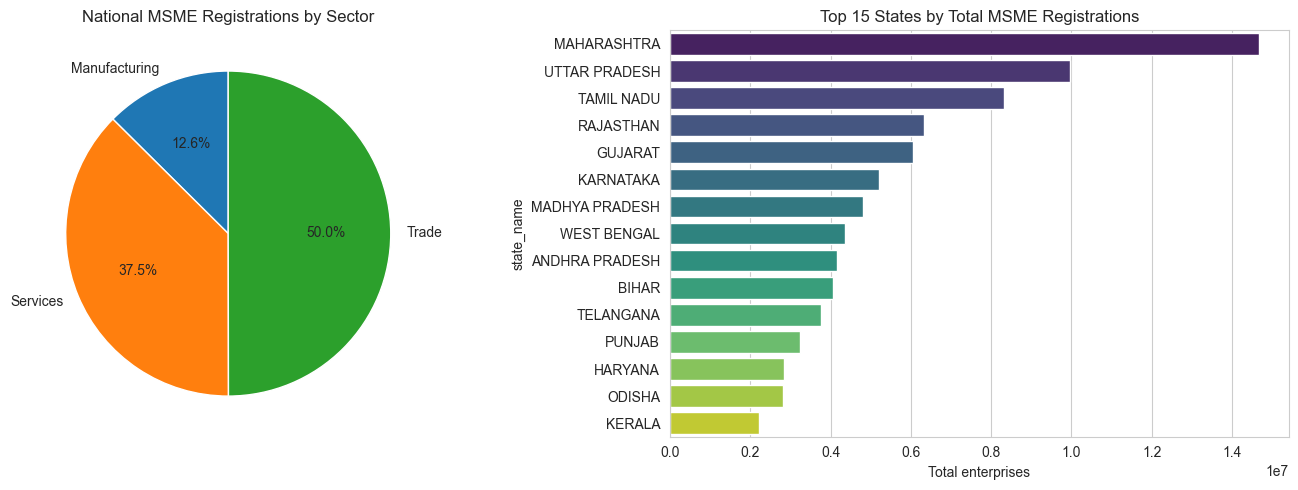

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sector_totals = df.groupby("sector")["total"].sum()
axes[0].pie(sector_totals, labels=sector_totals.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("National MSME Registrations by Sector")

state_totals = df.groupby("state_name")["total"].sum().sort_values(ascending=False).head(15)
sns.barplot(x=state_totals.values, y=state_totals.index, ax=axes[1], palette="viridis")
axes[1].set_title("Top 15 States by Total MSME Registrations")
axes[1].set_xlabel("Total enterprises")

plt.tight_layout()
plt.show()


## 3. Feature Engineering

For every district we compute:

| Feature | Meaning |
|---|---|
| `formal_ratio` | share of (small+medium) enterprises — market organization/maturity |
| `fragmentation_index` | share of `micro` enterprises — how informal/fragmented the market is |
| `competition_index` | district's total enterprises ÷ its state's average district total |
| `<Sector>_LQ` | Location Quotient — is this sector locally over/under-represented vs. the national mix? |


In [5]:
dist_tot = df.groupby(["state_name", "district_name", "lg_dt_code"], as_index=False).agg(
    total_enterprises=("total", "sum"),
    total_micro=("micro", "sum"),
    total_small=("small", "sum"),
    total_medium=("medium", "sum"),
)
dist_tot["formal_ratio"] = (dist_tot["total_small"] + dist_tot["total_medium"]) / dist_tot["total_enterprises"]

pivot = df.pivot_table(
    index=["state_name", "district_name", "lg_dt_code"],
    columns="sector", values="total", aggfunc="sum"
).reset_index()
pivot.columns.name = None

dist = dist_tot.merge(pivot, on=["state_name", "district_name", "lg_dt_code"])

state_avg = dist.groupby("state_name", as_index=False)["total_enterprises"].mean()
state_avg.columns = ["state_name", "state_avg_dist_enterprises"]
dist = dist.merge(state_avg, on="state_name")

national_sector_share = {s: df[df.sector == s]["total"].sum() / df["total"].sum() for s in SECTORS}

for s in SECTORS:
    dist[f"{s}_share"] = dist[s] / dist["total_enterprises"]
    dist[f"{s}_LQ"] = dist[f"{s}_share"] / national_sector_share[s]

dist["competition_index"] = dist["total_enterprises"] / dist["state_avg_dist_enterprises"]
dist["fragmentation_index"] = dist["total_micro"] / dist["total_enterprises"]

dist.describe().T


,count,mean,std,min,25%,50%,75%,max
lg_dt_code,788.0,386.796954,225.962135,1.000000,188.750000,385.500000,582.250000,7.880000e+02
total_enterprises,788.0,119743.373096,168901.627452,49.000000,30883.500000,76388.000000,142086.750000,2.174736e+06
total_micro,788.0,118402.899746,166187.675510,49.000000,30753.000000,75782.000000,140066.750000,2.148953e+06
total_small,788.0,1246.442893,2828.528429,0.000000,141.500000,467.000000,1148.000000,2.824900e+04
total_medium,788.0,94.030457,287.717176,0.000000,4.000000,20.000000,64.000000,3.938000e+03
formal_ratio,788.0,0.007976,0.006673,0.000000,0.004150,0.006275,0.009523,5.386733e-02
Manufacturing,788.0,15045.597716,22660.295123,2.000000,3379.750000,9145.500000,17689.000000,2.744770e+05
Services,788.0,44855.670051,63483.490205,23.000000,12021.500000,29294.000000,53551.500000,8.705470e+05
Trade,788.0,59842.105330,84415.076328,24.000000,15431.000000,38165.000000,71013.000000,1.086885e+06
state_avg_dist_enterprises,788.0,119743.373096,85692.638243,2285.111111,62259.314286,113991.393939,160430.692308,4.077501e+05


## 4. Composite Opportunity Score (0-100)

An explainable, weighted score — good for a quick shortlist and for explaining *why* a district
scored the way it did:

```
Opportunity_Score = 35% * (low competition)
                   + 25% * (market size, log enterprises -> demand/footfall proxy)
                   + 20% * (low formalization -> room for an organized entrant)
                   + 20% * (fragmentation -> informal-dominated market, easier to win share)
```

Plus a **sector-specific opportunity score** for Trade/Manufacturing/Services using each sector's
Location Quotient (LQ < 1 = under-represented locally = "white space").


In [6]:
def norm(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng else s * 0

dist["comp_score"] = 1 - norm(dist["competition_index"])
dist["frag_score"] = norm(dist["fragmentation_index"])
dist["size_score"] = norm(np.log1p(dist["total_enterprises"]))
dist["formal_score"] = 1 - norm(dist["formal_ratio"])

dist["Opportunity_Score"] = (
    0.35 * dist["comp_score"]
    + 0.25 * dist["size_score"]
    + 0.20 * dist["formal_score"]
    + 0.20 * dist["frag_score"]
) * 100

for s in SECTORS:
    raw = dist["Opportunity_Score"] * (1 / dist[f"{s}_LQ"].clip(lower=0.1))
    dist[f"{s}_Opportunity"] = norm(raw) * 100

dist.sort_values("Opportunity_Score", ascending=False)[
    ["state_name", "district_name", "Opportunity_Score", "total_enterprises"]
].head(10)


,state_name,district_name,Opportunity_Score,total_enterprises
420,MAHARASHTRA,SINDHUDURG,90.435667,114528
412,MAHARASHTRA,OSMANABAD,90.031162,174025
395,MAHARASHTRA,BHANDARA,89.857799,129355
417,MAHARASHTRA,RATNAGIRI,89.643863,175916
626,TAMIL NADU,TIRUPATHUR,89.599754,114761
22,ANDHRA PRADESH,SRI SATHYA SAI,89.095529,114505
609,TAMIL NADU,MAYILADUTHURAI,88.938078,69624
6,ANDHRA PRADESH,ANNAMAYYA,88.863921,123875
615,TAMIL NADU,RANIPET,88.767732,101719
394,MAHARASHTRA,BEED,88.760006,238927


## 5. Unsupervised Segmentation (KMeans)

In [7]:
FEATURE_COLS = [
    "competition_index", "fragmentation_index", "formal_ratio",
    "Trade_LQ", "Manufacturing_LQ", "Services_LQ", "total_enterprises",
]

X = dist[FEATURE_COLS].copy()
X["total_enterprises"] = np.log1p(X["total_enterprises"])

scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)

N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
dist["cluster"] = kmeans.fit_predict(Xs)

cluster_rank = dist.groupby("cluster")["Opportunity_Score"].mean().sort_values(ascending=False)
segment_names = [
    "High Opportunity (Underserved)",
    "Balanced Growth Market",
    "Competitive but Viable",
    "Saturated / High Competition",
][:N_CLUSTERS]
cluster_label_map = {cl: segment_names[i] for i, (cl, _) in enumerate(cluster_rank.items())}
dist["Segment"] = dist["cluster"].map(cluster_label_map)

dist["Segment"].value_counts()


Segment
High Opportunity (Underserved)    582
Balanced Growth Market            120
Saturated / High Competition       84
Competitive but Viable              2
Name: count, dtype: int64

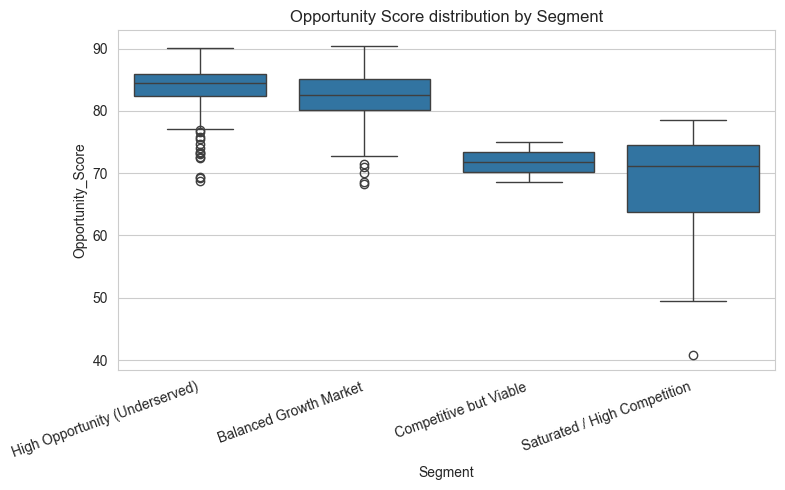

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=dist, x="Segment", y="Opportunity_Score",
            order=dist.groupby("Segment")["Opportunity_Score"].mean().sort_values(ascending=False).index)
plt.xticks(rotation=20, ha="right")
plt.title("Opportunity Score distribution by Segment")
plt.tight_layout()
plt.show()


## 6. Predictive Classifier

Train a `RandomForestClassifier` to predict a district's **Segment** from its engineered features.
This is the reusable *predictive* piece: once trained, it can score any district — including ones
not in this dataset — from just its raw enterprise counts (see `predict_new_district()` below).


In [9]:
y = dist["Segment"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print()
print(classification_report(y_test, preds))


Accuracy: 0.9683544303797469

                                precision    recall  f1-score   support

        Balanced Growth Market       0.96      0.96      0.96        24
High Opportunity (Underserved)       0.97      0.99      0.98       117
  Saturated / High Competition       0.93      0.82      0.88        17

                      accuracy                           0.97       158
                     macro avg       0.96      0.92      0.94       158
                  weighted avg       0.97      0.97      0.97       158



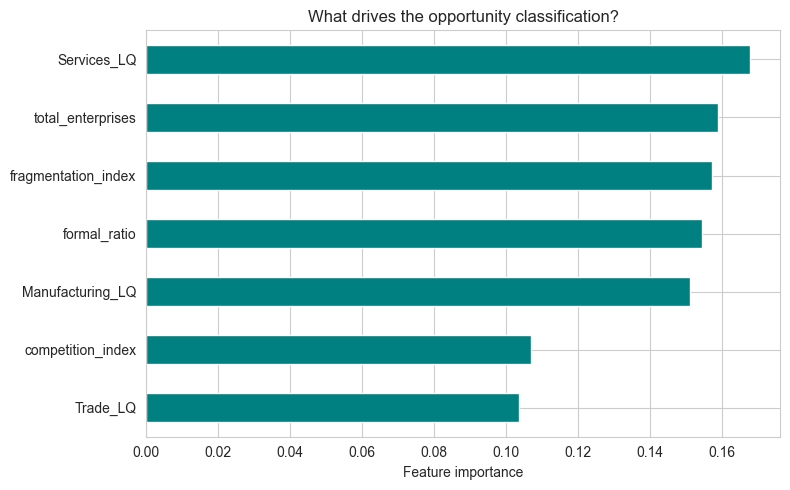

In [10]:
importances = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values()
plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="teal")
plt.title("What drives the opportunity classification?")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()


## 7. Rankings — overall, per sector, per state

In [11]:
def get_ranking(sector=None, state=None, top_n=15, ascending=False):
    score_col = "Opportunity_Score" if sector is None else f"{sector}_Opportunity"
    out = dist.copy()
    if state is not None:
        out = out[out["state_name"] == state.strip().upper()]
    cols = ["state_name", "district_name", score_col, "Segment", "total_enterprises",
            "formal_ratio", "competition_index", "fragmentation_index",
            "Trade_LQ", "Manufacturing_LQ", "Services_LQ"]
    return out.sort_values(score_col, ascending=ascending)[cols].head(top_n).reset_index(drop=True)

# Overall top 15
get_ranking(top_n=15)


,state_name,district_name,Opportunity_Score,Segment,total_enterprises,formal_ratio,competition_index,fragmentation_index,Trade_LQ,Manufacturing_LQ,Services_LQ
0,MAHARASHTRA,SINDHUDURG,90.435667,Balanced Growth Market,114528,0.002270,0.280878,0.997730,0.999656,1.414356,0.861475
1,MAHARASHTRA,OSMANABAD,90.031162,High Opportunity (Underserved),174025,0.003390,0.426793,0.996610,1.000052,0.886993,1.037836
2,MAHARASHTRA,BHANDARA,89.857799,Balanced Growth Market,129355,0.003247,0.317241,0.996753,1.000100,1.493421,0.834362
3,MAHARASHTRA,RATNAGIRI,89.643863,High Opportunity (Underserved),175916,0.003922,0.431431,0.996078,1.000267,1.129137,0.956329
4,TAMIL NADU,TIRUPATHUR,89.599754,Balanced Growth Market,114761,0.002161,0.524510,0.997839,1.000259,1.415230,0.860377
5,ANDHRA PRADESH,SRI SATHYA SAI,89.095529,Balanced Growth Market,114505,0.001869,0.713735,0.998131,1.000049,1.524945,0.823857
6,TAMIL NADU,MAYILADUTHURAI,88.938078,High Opportunity (Underserved),69624,0.002528,0.318213,0.997472,0.999747,0.732382,1.090102
7,ANDHRA PRADESH,ANNAMAYYA,88.863921,High Opportunity (Underserved),123875,0.002131,0.772140,0.997869,1.000099,1.018842,0.993549
8,TAMIL NADU,RANIPET,88.767732,Balanced Growth Market,101719,0.003205,0.464902,0.996795,1.000111,1.325732,0.890594
9,MAHARASHTRA,BEED,88.760006,High Opportunity (Underserved),238927,0.005290,0.585964,0.994710,1.000021,0.947708,1.017512


In [12]:
# Best districts specifically for a Trade shop
get_ranking(sector="Trade", top_n=10)


,state_name,district_name,Trade_Opportunity,Segment,total_enterprises,formal_ratio,competition_index,fragmentation_index,Trade_LQ,Manufacturing_LQ,Services_LQ
0,MAHARASHTRA,SINDHUDURG,100.000000,Balanced Growth Market,114528,0.002270,0.280878,0.997730,0.999656,1.414356,0.861475
1,MAHARASHTRA,OSMANABAD,99.112318,High Opportunity (Underserved),174025,0.003390,0.426793,0.996610,1.000052,0.886993,1.037836
2,MAHARASHTRA,BHANDARA,98.754089,Balanced Growth Market,129355,0.003247,0.317241,0.996753,1.000100,1.493421,0.834362
3,MAHARASHTRA,RATNAGIRI,98.292657,High Opportunity (Underserved),175916,0.003922,0.431431,0.996078,1.000267,1.129137,0.956329
4,TAMIL NADU,TIRUPATHUR,98.205179,Balanced Growth Market,114761,0.002161,0.524510,0.997839,1.000259,1.415230,0.860377
5,ANDHRA PRADESH,SRI SATHYA SAI,97.226640,Balanced Growth Market,114505,0.001869,0.713735,0.998131,1.000049,1.524945,0.823857
6,TAMIL NADU,MAYILADUTHURAI,96.963317,High Opportunity (Underserved),69624,0.002528,0.318213,0.997472,0.999747,0.732382,1.090102
7,ANDHRA PRADESH,ANNAMAYYA,96.750793,High Opportunity (Underserved),123875,0.002131,0.772140,0.997869,1.000099,1.018842,0.993549
8,MAHARASHTRA,BEED,96.555168,High Opportunity (Underserved),238927,0.005290,0.585964,0.994710,1.000021,0.947708,1.017512
9,TAMIL NADU,RANIPET,96.554713,Balanced Growth Market,101719,0.003205,0.464902,0.996795,1.000111,1.325732,0.890594


In [13]:
# Districts to avoid (already saturated)
get_ranking(ascending=True, top_n=10)


,state_name,district_name,Opportunity_Score,Segment,total_enterprises,formal_ratio,competition_index,fragmentation_index,Trade_LQ,Manufacturing_LQ,Services_LQ
0,ARUNACHAL PRADESH,PAPUM PARE,40.854082,Saturated / High Competition,19477,0.021461,8.523437,0.978539,0.999724,0.953311,1.016029
1,THE DADRA AND NAGAR HAVELI AND DAMAN AND DIU,DAMAN,49.427153,Saturated / High Competition,17695,0.048375,0.915559,0.951625,1.000099,1.128925,0.956624
2,DELHI,CENTRAL,50.896601,Saturated / High Competition,153284,0.053867,0.784954,0.946133,1.000207,1.249745,0.915954
3,WEST BENGAL,KOLKOTA,51.560949,Saturated / High Competition,391610,0.049386,2.069266,0.950614,1.000009,1.007046,0.997625
4,KARNATAKA,BENGALURU (URBAN),51.741135,Saturated / High Competition,1328729,0.023283,7.900771,0.976717,1.000049,0.900463,1.033321
5,CHHATTISGARH,RAIPUR,52.055442,Saturated / High Competition,266778,0.027139,6.067603,0.972861,0.999947,0.669713,1.110857
6,RAJASTHAN,JAIPUR,53.311020,Saturated / High Competition,1171410,0.013791,9.270898,0.986209,1.000105,1.272219,0.908552
7,PUDUCHERRY,MAHE,54.310166,Saturated / High Competition,1508,0.038462,0.047518,0.961538,1.000494,0.886645,1.037362
8,ARUNACHAL PRADESH,DIBANG VALLEY,54.572891,Saturated / High Competition,363,0.033058,0.158854,0.966942,0.997738,0.657744,1.117818
9,PUNJAB,FATEHGARH SAHIB,54.943041,Saturated / High Competition,68513,0.047407,0.485172,0.952593,1.000012,0.932327,1.022683


## 8. Score a brand-new / hypothetical district

Given only raw enterprise counts (e.g. from a fresh data pull, or a "what-if" scenario), predict
its opportunity segment and score — without re-running clustering on the whole dataset.


In [14]:
def predict_new_district(total_micro, total_small, total_medium,
                          trade, manufacturing, services,
                          state_name=None, state_avg_dist_enterprises=None):
    total_enterprises = total_micro + total_small + total_medium
    formal_ratio = (total_small + total_medium) / total_enterprises
    fragmentation_index = total_micro / total_enterprises

    if state_avg_dist_enterprises is None:
        if state_name is not None:
            match = dist.loc[dist["state_name"] == state_name.strip().upper(), "state_avg_dist_enterprises"]
            state_avg_dist_enterprises = match.iloc[0] if len(match) else dist["total_enterprises"].mean()
        else:
            state_avg_dist_enterprises = dist["total_enterprises"].mean()

    competition_index = total_enterprises / state_avg_dist_enterprises

    sector_totals = {"Trade": trade, "Manufacturing": manufacturing, "Services": services}
    lqs = {f"{s}_LQ": (sector_totals[s] / total_enterprises) / national_sector_share[s] for s in SECTORS}

    feat_row = pd.DataFrame([{
        "competition_index": competition_index,
        "fragmentation_index": fragmentation_index,
        "formal_ratio": formal_ratio,
        **lqs,
        "total_enterprises": np.log1p(total_enterprises),
    }])[FEATURE_COLS]

    segment = clf.predict(feat_row)[0]
    proba = dict(zip(clf.classes_, clf.predict_proba(feat_row)[0]))

    def norm_val(val, col):
        lo, hi = dist[col].min(), dist[col].max()
        return 0.0 if hi == lo else float(np.clip((val - lo) / (hi - lo), 0, 1))

    opp_score = (
        0.35 * (1 - norm_val(competition_index, "competition_index"))
        + 0.25 * norm_val(np.log1p(total_enterprises), "total_enterprises")
        + 0.20 * (1 - norm_val(formal_ratio, "formal_ratio"))
        + 0.20 * norm_val(fragmentation_index, "fragmentation_index")
    ) * 100

    return {
        "Opportunity_Score": round(opp_score, 2),
        "Predicted_Segment": segment,
        "Segment_Probabilities": {k: round(float(v), 3) for k, v in proba.items()},
        "sector_location_quotients": {k: round(v, 3) for k, v in lqs.items()},
    }

# Example: a hypothetical district in Karnataka
predict_new_district(
    total_micro=40000, total_small=800, total_medium=50,
    trade=25000, manufacturing=8000, services=7850,
    state_name="KARNATAKA",
)


{'Opportunity_Score': 58.7,
 'Predicted_Segment': 'Balanced Growth Market',
 'Segment_Probabilities': {'Balanced Growth Market': 0.56,
  'Competitive but Viable': 0.02,
  'High Opportunity (Underserved)': 0.047,
  'Saturated / High Competition': 0.373},
 'sector_location_quotients': {'Trade_LQ': np.float64(1.225),
  'Manufacturing_LQ': np.float64(1.559),
  'Services_LQ': np.float64(0.513)}}

## 8b. Plain-language verdict: "is this a good option?"

Wraps the score/segment into a direct verdict, and works two ways:

- **District already in your data** → just pass `district_name` + `state_name` (+ optional `sector`) and it looks the row up.
- **New district / your own numbers** → pass the 6 raw counts (`total_micro`, `total_small`, `total_medium`, `trade`, `manufacturing`, `services`) and it predicts.


In [15]:
def evaluate_district(district_name=None, state_name=None, sector=None,
                       total_micro=None, total_small=None, total_medium=None,
                       trade=None, manufacturing=None, services=None):
    looked_up = False
    if district_name is not None:
        match = dist[
            (dist["district_name"] == district_name.strip().upper())
            & ((state_name is None) | (dist["state_name"] == state_name.strip().upper()))
        ]
        if len(match):
            row = match.iloc[0]
            looked_up = True
            score = row["Opportunity_Score"] if sector is None else row[f"{sector}_Opportunity"]
            segment = row["Segment"]
            proba = None
            comp, frag, formal = row["competition_index"], row["fragmentation_index"], row["formal_ratio"]

    if not looked_up:
        missing = [n for n, v in [("total_micro", total_micro), ("total_small", total_small),
                                   ("total_medium", total_medium), ("trade", trade),
                                   ("manufacturing", manufacturing), ("services", services)] if v is None]
        if missing:
            raise ValueError(f"District not found in data, and missing inputs to predict it: {missing}")
        pred = predict_new_district(total_micro, total_small, total_medium, trade, manufacturing, services, state_name)
        score = pred["Opportunity_Score"]
        segment = pred["Predicted_Segment"]
        proba = pred["Segment_Probabilities"]
        comp = pred["sector_location_quotients"]  # not directly comp_index; recompute below for reasoning
        # recompute raw diagnostics for the reasoning text
        total_enterprises = total_micro + total_small + total_medium
        formal = (total_small + total_medium) / total_enterprises
        frag = total_micro / total_enterprises
        state_avg = dist.loc[dist["state_name"] == state_name.strip().upper(), "state_avg_dist_enterprises"]
        state_avg = state_avg.iloc[0] if len(state_avg) else dist["total_enterprises"].mean()
        comp = total_enterprises / state_avg

    if segment == "High Opportunity (Underserved)":
        verdict = "GOOD OPTION -- under-served relative to its market size"
    elif segment == "Balanced Growth Market":
        verdict = "REASONABLE OPTION -- healthy, moderately competitive market"
    elif segment == "Competitive but Viable":
        verdict = "PROCEED WITH CAUTION -- viable but competitive"
    else:
        verdict = "RISKY -- already saturated with competitors"

    reasons = [
        f"Competition index {comp:.2f} ({'below' if comp < 1 else 'above'} state-average district density).",
        f"Fragmentation index {frag:.2f} ({'highly informal-dominated market' if frag > 0.9 else 'more formalized market'}).",
        f"Formal ratio {formal:.3f} (share already organized/small+medium scale).",
    ]

    return {
        "Verdict": verdict,
        "Segment": segment,
        "Opportunity_Score": round(float(score), 2),
        "Segment_Probabilities": proba,
        "Reasoning": reasons,
        "Source": "looked up from training data" if looked_up else "predicted from supplied counts",
    }

# Example A: district already in the data
print(evaluate_district(district_name="SINDHUDURG", state_name="MAHARASHTRA", sector="Trade"))
print()
# Example B: a saturated district, for contrast
print(evaluate_district(district_name="BENGALURU (URBAN)", state_name="KARNATAKA"))
print()
# Example C: brand-new district from raw counts
print(evaluate_district(
    state_name="KARNATAKA", sector="Trade",
    total_micro=40000, total_small=800, total_medium=50,
    trade=25000, manufacturing=8000, services=7850,
))


{'Verdict': 'REASONABLE OPTION -- healthy, moderately competitive market', 'Segment': 'Balanced Growth Market', 'Opportunity_Score': 100.0, 'Segment_Probabilities': None, 'Reasoning': ['Competition index 0.28 (below state-average district density).', 'Fragmentation index 1.00 (highly informal-dominated market).', 'Formal ratio 0.002 (share already organized/small+medium scale).'], 'Source': 'looked up from training data'}

{'Verdict': 'RISKY -- already saturated with competitors', 'Segment': 'Saturated / High Competition', 'Opportunity_Score': 51.74, 'Segment_Probabilities': None, 'Reasoning': ['Competition index 7.90 (above state-average district density).', 'Fragmentation index 0.98 (highly informal-dominated market).', 'Formal ratio 0.023 (share already organized/small+medium scale).'], 'Source': 'looked up from training data'}

{'Verdict': 'REASONABLE OPTION -- healthy, moderately competitive market', 'Segment': 'Balanced Growth Market', 'Opportunity_Score': 58.7, 'Segment_Probabil

## 9. Save everything for reuse in other software

In [16]:
dist.to_csv("district_scored.csv", index=False)

joblib.dump({
    "district_df": dist,
    "scaler": scaler,
    "kmeans": kmeans,
    "classifier": clf,
    "national_sector_share": national_sector_share,
    "cluster_label_map": cluster_label_map,
    "feature_cols": FEATURE_COLS,
}, "msme_model.joblib")

print("Saved district_scored.csv and msme_model.joblib")


Saved district_scored.csv and msme_model.joblib


### Reload later / in another app

```python
import joblib
obj = joblib.load("msme_model.joblib")
clf = obj["classifier"]
dist = obj["district_df"]
# ... use predict_new_district()-style logic with these objects
```

Or, for a fully packaged, class-based version of this exact pipeline (drop-in importable module
with `MSMEOpportunityModel`), see the accompanying `msme_opportunity_model.py` file.
